# Task 1: Condition Classification
**Objective:** Build a classifier to identify the treatment condition of a cell based on its gene expression profile. 

**Models:** Sklearn MLPClassifier (Baseline) and PyTorch Custom MLP (Advanced).

**Experimental Design:** We use an 80/20 train-test split, stratified by condition to ensure class balance across splits.

In [2]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import TensorDataset, DataLoader

In [3]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [4]:
# Define paths
data_path = "../data/frangieh/adata_preprocessed.h5ad"
output_path = "../results/t1/neuralnetwork/"
os.makedirs(output_path, exist_ok=True)

In [5]:
## Load the data
adata = sc.read_h5ad("../data/frangieh/adata_preprocessed.h5ad")

In [6]:
# Feature Selection: Restrict to Highly Variable Genes
adata = adata[:, adata.var.highly_variable]
X_data = adata.X.toarray()

In [7]:
## Stratified Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_data, adata.obs['condition'], test_size=0.2, random_state=42, stratify=adata.obs['condition'])

In [8]:
classes = adata.obs['condition'].unique().tolist()

# sklearn version

In [9]:
# Sklearn Baseline Model

mlp_clf = MLPClassifier(hidden_layer_sizes=[300, 100], verbose=True, early_stopping=True, random_state=42)
pipeline = make_pipeline(StandardScaler(), mlp_clf)
pipeline.fit(X_train, y_train)

baseline_accuracy = pipeline.score(X_test, y_test)
print(f"Sklearn Baseline Model Accuracy: {baseline_accuracy:.4f}")

Iteration 1, loss = 0.07873745
Validation score: 0.981459
Iteration 2, loss = 0.03187293
Validation score: 0.982040
Iteration 3, loss = 0.01807942
Validation score: 0.982234
Iteration 4, loss = 0.01042432
Validation score: 0.982492
Iteration 5, loss = 0.00618111
Validation score: 0.983655
Iteration 6, loss = 0.00518933
Validation score: 0.983268
Iteration 7, loss = 0.00527739
Validation score: 0.981394
Iteration 8, loss = 0.00611611
Validation score: 0.983526
Iteration 9, loss = 0.00541455
Validation score: 0.982751
Iteration 10, loss = 0.00377969
Validation score: 0.983203
Iteration 11, loss = 0.00233229
Validation score: 0.982880
Iteration 12, loss = 0.00198822
Validation score: 0.983009
Iteration 13, loss = 0.00168137
Validation score: 0.983914
Iteration 14, loss = 0.00425621
Validation score: 0.982428
Iteration 15, loss = 0.00294177
Validation score: 0.980102
Iteration 16, loss = 0.00324487
Validation score: 0.983397
Iteration 17, loss = 0.00244450
Validation score: 0.982751
Iterat

# pytorch version

In [10]:
# Hardware acceleration setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ConditionClassifierMLP(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes, dropout_rate=0.3):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            
            nn.Linear(n_inputs, n_hidden1),
            nn.BatchNorm1d(n_hidden1), # Stabilizes training across varying gene expression distributions
            nn.ReLU(),
            nn.Dropout(p=dropout_rate), # Regularization to prevent overfitting on sparse single-cell dropout noise
            
            nn.Linear(n_hidden1, n_hidden2),
            nn.BatchNorm1d(n_hidden2), 
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            
            nn.Linear(n_hidden2, n_classes)
        )
        
    def forward(self, X):
        return self.mlp(X)

In [11]:
# Initialize Model, Loss, and Optimizer
model = ConditionClassifierMLP(n_inputs=X_train.shape[1], n_hidden1=300, n_hidden2=100, n_classes=len(classes)).to(device)
xentropy = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [12]:
class_to_idx = {name: idx for idx, name in enumerate(classes)}
y_train_idx = [class_to_idx[label] for name, label in y_train.items()]
y_test_idx = [class_to_idx[label] for name, label in y_test.items()]

y_train_tensor = torch.tensor(y_train_idx, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_idx, dtype=torch.long)

if hasattr(X_train, "toarray"):
    X_train_tensor = torch.tensor(X_train.toarray(), dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test.toarray(), dtype=torch.float32)
else:
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

In [13]:
# Combine X and y into a standard unified PyTorch Dataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders for chunking data into manageable mini-batches
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [14]:
# Track loss values over time to monitor training convergence
loss_history = []
EPOCHS = 20

model.train()  # Set the model to training mode
for epoch in range(EPOCHS):
    running_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        # Move mini-batch tensors directly onto hardware device (CPU)
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        # Clear out stale gradients from the previous iteration step
        optimizer.zero_grad()
        
        # Run the forward execution pass to generate class predictions
        predictions = model(batch_X)
        
        # Measure prediction performance error using Cross Entropy
        loss = xentropy(predictions, batch_y)
        
        # Perform backpropagation to calculate error gradients
        loss.backward()
        
        # Tweak internal model weights using the Adam optimizer
        optimizer.step()
        
        running_loss += loss.item() * batch_X.size(0)
        
    epoch_loss = running_loss / len(train_loader.dataset)
    loss_history.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{EPOCHS}] -> Training Loss: {epoch_loss:.4f}")

Epoch [1/20] -> Training Loss: 0.0553
Epoch [2/20] -> Training Loss: 0.0402
Epoch [3/20] -> Training Loss: 0.0358
Epoch [4/20] -> Training Loss: 0.0310
Epoch [5/20] -> Training Loss: 0.0270
Epoch [6/20] -> Training Loss: 0.0230
Epoch [7/20] -> Training Loss: 0.0197
Epoch [8/20] -> Training Loss: 0.0170
Epoch [9/20] -> Training Loss: 0.0148
Epoch [10/20] -> Training Loss: 0.0135
Epoch [11/20] -> Training Loss: 0.0116
Epoch [12/20] -> Training Loss: 0.0106
Epoch [13/20] -> Training Loss: 0.0093
Epoch [14/20] -> Training Loss: 0.0090
Epoch [15/20] -> Training Loss: 0.0088
Epoch [16/20] -> Training Loss: 0.0078
Epoch [17/20] -> Training Loss: 0.0067
Epoch [18/20] -> Training Loss: 0.0064
Epoch [19/20] -> Training Loss: 0.0069
Epoch [20/20] -> Training Loss: 0.0061



Evaluation Complete!
Final Validation Accuracy: 98.86%

Classification Report:
              precision    recall  f1-score   support

     Control       0.97      0.98      0.98      9956
        IFNγ       0.99      0.98      0.99     14976
  Co-culture       1.00      1.00      1.00     13765

    accuracy                           0.99     38697
   macro avg       0.99      0.99      0.99     38697
weighted avg       0.99      0.99      0.99     38697



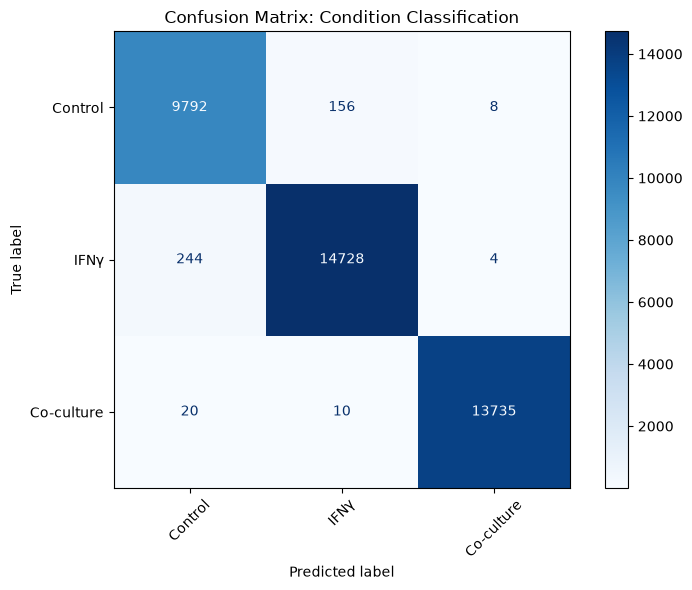

<Figure size 640x480 with 0 Axes>

In [15]:
model.eval()  # Set the model to evaluation mode
correct_predictions = 0
total_samples = 0

# Initialize lists to store all predictions and true labels
all_preds = []
all_true = []

# Deactivate gradient tracking memory allocation since we are only calculating predictions
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        # Forward pass execution
        outputs = model(batch_X)
        
        # Determine the prediction index with the highest logit score probability
        _, predicted_classes = torch.max(outputs, dim=1)
        
        # Accumulate metrics
        total_samples += batch_y.size(0)
        correct_predictions += (predicted_classes == batch_y).sum().item()
        
        # Store batch predictions and true labels for Scikit-learn
        # We must move tensors back to the CPU and convert to numpy arrays
        all_preds.extend(predicted_classes.cpu().numpy())
        all_true.extend(batch_y.cpu().numpy())

# Print standard accuracy
final_accuracy = (correct_predictions / total_samples) * 100
print(f"\nEvaluation Complete!")
print(f"Final Validation Accuracy: {final_accuracy:.2f}%\n")

# Generate the Classification Report
print("Classification Report:")
print(classification_report(all_true, all_preds, target_names=classes))

# Plot the Confusion Matrix
cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix: Condition Classification")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# save the plot
plt.savefig(f"{output_path}confusion_matrix.png")

In [16]:
def compute_permutation_importance(model, X_test, y_test, feature_names, device):
    model.eval()
    
    # 1. Calculate baseline accuracy
    with torch.no_grad():
        X_test = X_test.to(device)
        y_test = y_test.to(device)
        baseline_outputs = model(X_test)
        baseline_preds = torch.argmax(baseline_outputs, dim=1)
        baseline_acc = (baseline_preds == y_test).float().mean().item()
    
    importances = []
    num_features = X_test.shape[1]
    
    print(f"Baseline Accuracy: {baseline_acc:.4f}")
    print("Calculating permutation importances (this may take a while)...")
    
    # 2. Iterate over each feature
    for i in range(num_features):
        # Create a copy of the test data so we don't permanently alter it
        X_test_shuffled = X_test.clone()
        
        # Shuffle the i-th feature column
        shuffled_indices = torch.randperm(X_test.shape[0])
        X_test_shuffled[:, i] = X_test_shuffled[shuffled_indices, i]
        
        # 3. Calculate accuracy with the shuffled feature
        with torch.no_grad():
            shuffled_outputs = model(X_test_shuffled)
            shuffled_preds = torch.argmax(shuffled_outputs, dim=1)
            shuffled_acc = (shuffled_preds == y_test).float().mean().item()
            
        # 4. The importance is the drop in accuracy
        drop = baseline_acc - shuffled_acc
        importances.append(drop)
        
        # Optional: Print progress for long runs
        if (i + 1) % 500 == 0:
            print(f"Processed {i + 1}/{num_features} features...")

    return np.array(importances)

# Note: You need a list of your gene names corresponding to the columns in X_data
# For example: gene_names = adata.var_names.tolist()
gene_names = adata.var_names.tolist()

# Run the function
importances = compute_permutation_importance(model, X_test_tensor, y_test_tensor, gene_names, device)

Baseline Accuracy: 0.9886
Calculating permutation importances (this may take a while)...
Processed 500/2000 features...
Processed 1000/2000 features...
Processed 1500/2000 features...
Processed 2000/2000 features...


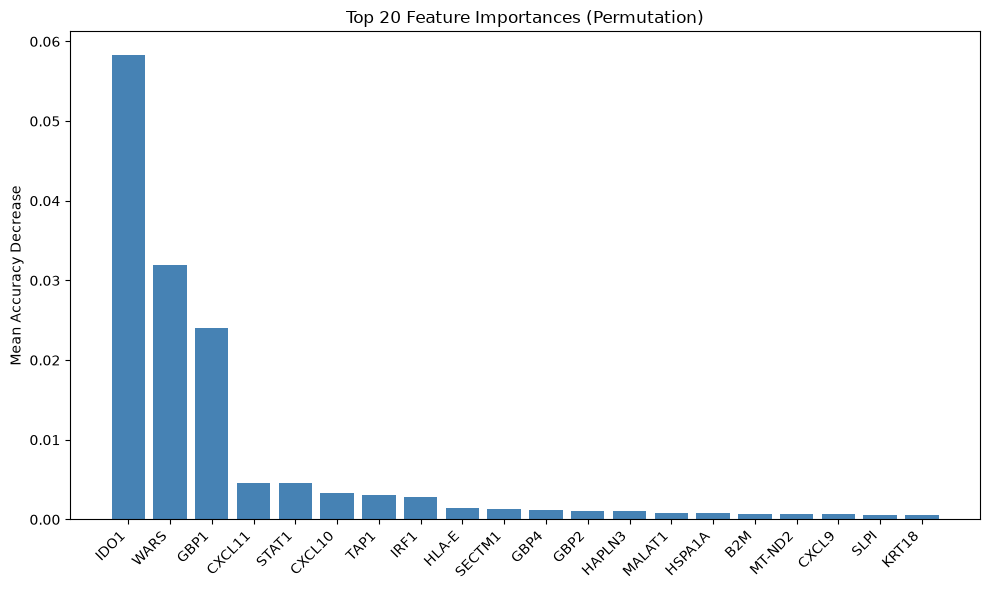

<Figure size 640x480 with 0 Axes>

In [17]:
def plot_top_features(importances, feature_names, top_n=20):
    # Sort indices by importance (descending)
    sorted_indices = np.argsort(importances)[::-1]
    
    top_indices = sorted_indices[:top_n]
    top_importances = importances[top_indices]
    top_features = [feature_names[i] for i in top_indices]
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    plt.bar(range(top_n), top_importances, align='center', color='steelblue')
    plt.xticks(range(top_n), top_features, rotation=45, ha='right')
    plt.ylabel('Mean Accuracy Decrease')
    plt.title(f'Top {top_n} Feature Importances (Permutation)')
    plt.tight_layout()
    plt.show()
    plt.savefig(f"{output_path}top_{top_n}_feature_importances.png")

# Visualize the top 20 genes
plot_top_features(importances, gene_names, top_n=20)